# Confirmation Bias & Belief Perseverance in Incident Response

Part 0 introduced behavioral biases at a surface level -- anchoring warps
estimates, overconfidence inflates certainty, framing flips preferences.
Those are the entry-level distortions. This notebook goes deeper.

Incident response is where cognitive biases do the most operational damage.
An IR analyst forms a hypothesis in the first ten minutes of triage. From
that point forward, every piece of evidence is filtered through that
hypothesis. Confirming evidence gets amplified. Disconfirming evidence gets
explained away. The investigation converges on the wrong root cause, and
the real attacker keeps moving.

This notebook covers five traps that routinely corrupt IR decisions:

1. **Belief perseverance** -- clinging to the initial hypothesis after the evidence has shifted
2. **Confirmation bias** -- selectively weighting evidence that supports what you already believe
3. **Sunk cost** -- continuing a failed investigation because of what you have already spent
4. **Resulting** -- evaluating decision quality by outcome rather than process
5. **Structured debiasing** -- Analysis of Competing Hypotheses as a countermeasure

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.bayes import beta_update, brier_score

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. Belief Perseverance in Triage

An IR analyst gets paged at 2 AM. The SIEM alert shows repeated failed
login attempts from an employee's account -- off-hours, unusual
geolocation, escalating privilege requests. The analyst forms an
immediate hypothesis: **insider threat**.

Then evidence starts arriving. Some of it supports the insider hypothesis.
Some of it points strongly toward compromised credentials -- an external
attacker using stolen creds. A rational Bayesian updater adjusts their
belief with each new piece of evidence, regardless of direction. A human
analyst experiencing belief perseverance does not.

> "Once we've decided that this is what we're going to do, especially if
> we've put money behind that decision, everything that we look at is about
> how great it is."

The mechanism is simple: after forming a hypothesis, the analyst
unconsciously raises the bar for disconfirming evidence while lowering it
for confirming evidence. The initial hypothesis becomes sticky -- not
because the evidence supports it, but because the analyst has committed
to it.

We model this with sequential Bayesian updates. Each piece of evidence
has a true likelihood ratio (how strongly it favors insider vs external).
The rational analyst applies these ratios faithfully. The belief-perseverant
analyst dampens updates that contradict the initial hypothesis.

In [2]:
# --- Belief Perseverance: Rational vs Human Analyst ---

# Evidence sequence: each item is (description, likelihood_ratio_for_insider)
# LR > 1 means evidence favors insider; LR < 1 means evidence favors external attacker
evidence = [
    ("Failed logins from employee's home IP",          3.0),   # supports insider
    ("Access attempts on HR database (employee's dept)", 2.5), # supports insider
    ("Credential found on dark-web paste (3 days old)", 0.15), # strongly favors external
    ("USB device plugged in at employee's workstation", 2.0),  # supports insider
    ("Login from TOR exit node using same credentials", 0.10), # strongly favors external
]

# Prior: P(insider) = 0.70 after initial triage (analyst's gut read)
prior_insider = 0.70

# --- Rational Bayesian updater ---
rational_trajectory = [prior_insider]
odds = prior_insider / (1 - prior_insider)  # prior odds

for desc, lr in evidence:
    odds *= lr
    posterior = odds / (1 + odds)
    rational_trajectory.append(posterior)

# --- Belief-perseverant analyst ---
# Dampens disconfirming evidence (LR < 1 gets pulled toward 1.0)
# Slightly amplifies confirming evidence (LR > 1 gets a small boost)
DAMPEN = 0.4   # disconfirming evidence has only 40% of its true log-impact
AMPLIFY = 1.2  # confirming evidence gets 20% boost in log-space

biased_trajectory = [prior_insider]
biased_odds = prior_insider / (1 - prior_insider)

for desc, lr in evidence:
    log_lr = np.log(lr)
    if lr < 1:
        # Disconfirming: dampen the update
        adjusted_log_lr = log_lr * DAMPEN
    else:
        # Confirming: slight amplification
        adjusted_log_lr = log_lr * AMPLIFY
    biased_odds *= np.exp(adjusted_log_lr)
    posterior = biased_odds / (1 + biased_odds)
    biased_trajectory.append(posterior)

# Print the trajectories
labels = ["Prior"] + [e[0][:45] + "..." if len(e[0]) > 45 else e[0] for e, _ in
                      zip(evidence, range(len(evidence)))]
# Fix: just use evidence descriptions
labels = ["Prior"] + [desc[:50] for desc, _ in evidence]

print(f"{'Step':<55} {'Rational':>10} {'Biased':>10}")
print("-" * 77)
for i, label in enumerate(labels):
    print(f"{label:<55} {rational_trajectory[i]:>10.3f} {biased_trajectory[i]:>10.3f}")

Step                                                      Rational     Biased
-----------------------------------------------------------------------------
Prior                                                        0.700      0.700
Failed logins from employee's home IP                        0.875      0.897
Access attempts on HR database (employee's dept)             0.946      0.963
Credential found on dark-web paste (3 days old)              0.724      0.925
USB device plugged in at employee's workstation              0.840      0.966
Login from TOR exit node using same credentials              0.344      0.918


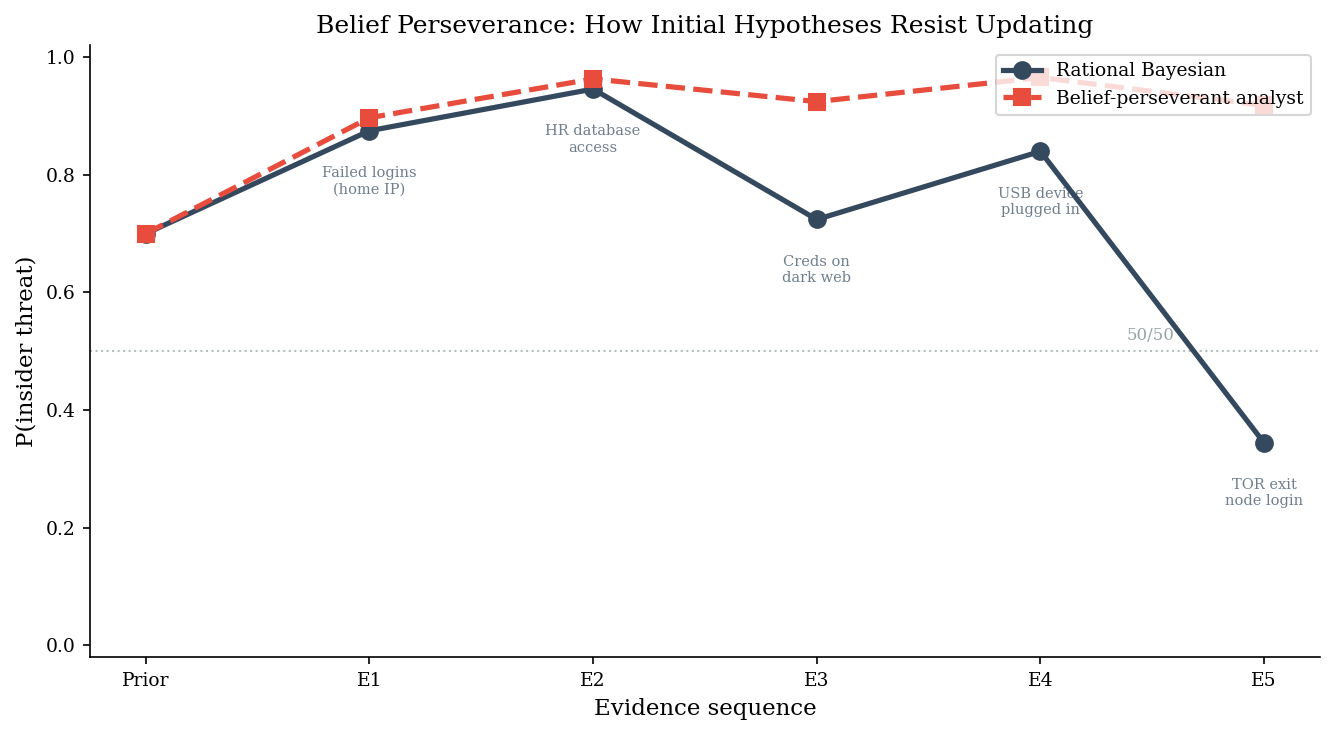


After all evidence:
  Rational analyst:  P(insider) = 0.344
  Biased analyst:    P(insider) = 0.918
  Gap:               +0.574

The rational analyst has shifted to favor external attacker.
The biased analyst still thinks it's probably an insider.


In [3]:
# --- Plot: Rational vs Belief-Perseverant Trajectories ---

fig, ax = plt.subplots(figsize=(9, 5))

steps = range(len(rational_trajectory))
ax.plot(steps, rational_trajectory, "o-", color=DARK_BG, lw=2.5,
        markersize=8, label="Rational Bayesian", zorder=3)
ax.plot(steps, biased_trajectory, "s--", color=ACCENT, lw=2.5,
        markersize=8, label="Belief-perseverant analyst", zorder=3)

ax.axhline(0.5, color=LIGHT_GRAY, ls=":", lw=1, alpha=0.7)
ax.text(4.6, 0.52, "50/50", color=LIGHT_GRAY, fontsize=8, ha="right")

# Annotate evidence items
evidence_labels_short = [
    "Failed logins\n(home IP)",
    "HR database\naccess",
    "Creds on\ndark web",
    "USB device\nplugged in",
    "TOR exit\nnode login",
]
for i, label in enumerate(evidence_labels_short):
    ax.annotate(label, xy=(i + 1, rational_trajectory[i + 1]),
                xytext=(0, -30), textcoords="offset points",
                fontsize=7, ha="center", color=DARK_BG, alpha=0.7)

ax.set_xticks(steps)
ax.set_xticklabels(["Prior"] + [f"E{i+1}" for i in range(len(evidence))])
ax.set_xlabel("Evidence sequence")
ax.set_ylabel("P(insider threat)")
ax.set_title("Belief Perseverance: How Initial Hypotheses Resist Updating")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"\nAfter all evidence:")
print(f"  Rational analyst:  P(insider) = {rational_trajectory[-1]:.3f}")
print(f"  Biased analyst:    P(insider) = {biased_trajectory[-1]:.3f}")
print(f"  Gap:               {biased_trajectory[-1] - rational_trajectory[-1]:+.3f}")
print(f"\nThe rational analyst has shifted to favor external attacker.")
print(f"The biased analyst still thinks it's probably an insider.")

## 2. Confirmation Bias: Selective Evidence Gathering

Belief perseverance is about *updating*. Confirmation bias is about
*gathering*. The biased analyst does not just under-weight contradictory
evidence -- they actively seek evidence that confirms their hypothesis
and avoid evidence that might refute it.

In practice, this manifests as selective attention to likelihood ratios.
When evidence supports the working hypothesis, the analyst inflates its
diagnostic value ("this is exactly what we'd expect to see"). When
evidence contradicts the hypothesis, the analyst discounts it ("that
could mean anything").

**Scenario:** An IR team is investigating a data exfiltration alert.
The DLP system flagged 2 GB of data leaving the network to an external
IP. The lead analyst's initial hypothesis is **malicious insider**.

We construct eight pieces of evidence -- four that genuinely support
the insider hypothesis and four that support an alternative explanation
(misconfigured DLP rule generating a false positive). Each item has a
true likelihood ratio. The confirmation-biased analyst inflates LRs for
hypothesis-consistent evidence by 2x and discounts inconsistent evidence
by 0.5x.

In [4]:
# --- Confirmation Bias: Selective Evidence Weighting ---

# Evidence items for the data exfiltration investigation
# LR > 1 favors "malicious insider"; LR < 1 favors "misconfigured DLP"
evidence_items = pd.DataFrame({
    "Evidence": [
        "Employee accessed sensitive files outside role",
        "Transfer occurred after business hours",
        "Employee recently passed over for promotion",
        "Destination IP linked to personal cloud storage",
        "DLP rule was updated 48 hours before alert",
        "Same alert pattern seen on 3 other endpoints",
        "Transfer matches scheduled backup job timing",
        "No encryption on transferred data (backup uses TLS)",
    ],
    "True LR": [3.0, 1.8, 2.0, 2.5, 0.20, 0.15, 0.25, 1.5],
    "Direction": [
        "Insider", "Insider", "Insider", "Insider",
        "DLP misconfig", "DLP misconfig", "DLP misconfig", "Insider",
    ],
})

# Biased analyst: inflate consistent, discount inconsistent
# Hypothesis = insider, so LR > 1 is consistent
INFLATE = 2.0
DISCOUNT = 0.5

biased_lrs = []
for _, row in evidence_items.iterrows():
    lr = row["True LR"]
    if lr >= 1.0:
        biased_lrs.append(lr * INFLATE)
    else:
        # Discount the disconfirming power: pull LR toward 1.0
        # LR=0.2 becomes 0.2^0.5 = 0.45 (less disconfirming)
        biased_lrs.append(lr ** DISCOUNT)

evidence_items["Biased LR"] = biased_lrs

print(evidence_items[["Evidence", "True LR", "Biased LR", "Direction"]].to_string(index=False))

                                           Evidence  True LR  Biased LR     Direction
     Employee accessed sensitive files outside role     3.00   6.000000       Insider
             Transfer occurred after business hours     1.80   3.600000       Insider
        Employee recently passed over for promotion     2.00   4.000000       Insider
    Destination IP linked to personal cloud storage     2.50   5.000000       Insider
         DLP rule was updated 48 hours before alert     0.20   0.447214 DLP misconfig
       Same alert pattern seen on 3 other endpoints     0.15   0.387298 DLP misconfig
       Transfer matches scheduled backup job timing     0.25   0.500000 DLP misconfig
No encryption on transferred data (backup uses TLS)     1.50   3.000000       Insider


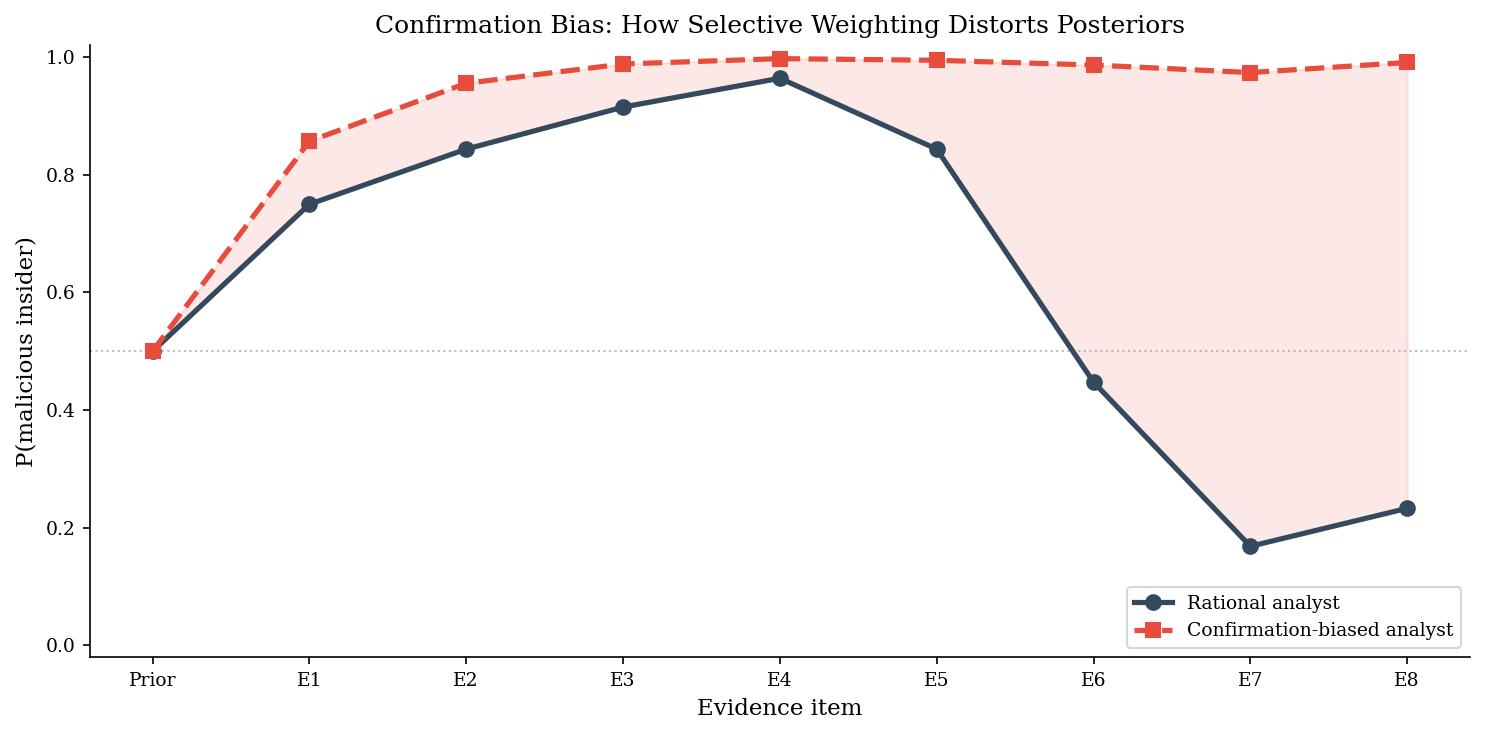


Final P(insider):
  Rational analyst:  0.233
  Biased analyst:    0.991

The same eight pieces of evidence lead to opposite conclusions
depending on how the analyst weights them.


In [5]:
# --- Plot: Posterior divergence between rational and biased analyst ---

prior_p = 0.50  # start at 50/50 for this scenario

# Compute cumulative posteriors
def compute_trajectory(prior, likelihood_ratios):
    """Apply sequential LR updates, return list of posteriors."""
    trajectory = [prior]
    odds = prior / (1 - prior)
    for lr in likelihood_ratios:
        odds *= lr
        trajectory.append(odds / (1 + odds))
    return trajectory

rational_traj = compute_trajectory(prior_p, evidence_items["True LR"].values)
biased_traj = compute_trajectory(prior_p, evidence_items["Biased LR"].values)

fig, ax = plt.subplots(figsize=(10, 5))

steps = range(len(rational_traj))
ax.plot(steps, rational_traj, "o-", color=DARK_BG, lw=2.5, markersize=7,
        label="Rational analyst", zorder=3)
ax.plot(steps, biased_traj, "s--", color=ACCENT, lw=2.5, markersize=7,
        label="Confirmation-biased analyst", zorder=3)

ax.axhline(0.5, color=LIGHT_GRAY, ls=":", lw=1, alpha=0.7)

# Shade the divergence
ax.fill_between(steps, rational_traj, biased_traj, alpha=0.12, color=ACCENT)

ax.set_xticks(steps)
xlabels = ["Prior"] + [f"E{i+1}" for i in range(len(evidence_items))]
ax.set_xticklabels(xlabels)
ax.set_xlabel("Evidence item")
ax.set_ylabel("P(malicious insider)")
ax.set_title("Confirmation Bias: How Selective Weighting Distorts Posteriors")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nFinal P(insider):")
print(f"  Rational analyst:  {rational_traj[-1]:.3f}")
print(f"  Biased analyst:    {biased_traj[-1]:.3f}")
print(f"\nThe same eight pieces of evidence lead to opposite conclusions")
print(f"depending on how the analyst weights them.")

## 3. Sunk Cost in Incident Containment

An organization has spent three weeks and \$200K investigating what they
believe is a nation-state APT. The CISO has briefed the board. The IR
firm has deployed custom detection signatures. The threat intel team has
built a profile of the suspected actor.

Then the forensics team finds evidence that this is commodity ransomware.
The C2 infrastructure matches a known ransomware-as-a-service operator.
The lateral movement pattern is textbook Conti playbook. The probability
that this is actually an APT has dropped to 20%.

The rational decision depends only on **future costs and probabilities**.
The \$200K already spent is gone regardless of what happens next. But the
sunk cost fallacy pulls the team toward continuing the APT investigation
("we've already invested so much, we can't pivot now").

We model two decision paths and compare their expected costs.

In [6]:
# --- Sunk Cost Decision Analysis ---

sunk_cost = 200_000  # already spent -- irrelevant to forward decision

# Current belief: P(APT) = 0.20, P(ransomware) = 0.80
p_apt = 0.20
p_ransomware = 0.80

# Option A: Continue APT investigation
#   - $50K/week for ~3 more weeks
#   - If it IS an APT: successful containment (saves $2M in potential damage)
#   - If it's ransomware: wasted weeks, ransomware spreads, +$500K in damages
apt_weekly_cost = 50_000
apt_weeks = 3
apt_investigation_cost = apt_weekly_cost * apt_weeks  # $150K

apt_if_correct = apt_investigation_cost                      # $150K (contained)
apt_if_wrong = apt_investigation_cost + 500_000              # $650K (wasted + damage)

ev_continue_apt = p_apt * apt_if_correct + p_ransomware * apt_if_wrong

# Option B: Pivot to ransomware playbook
#   - $20K one-time pivot cost
#   - If it IS ransomware: quick containment (saves $500K in spread damage)
#   - If it's actually APT: miss the APT, $300K in additional damage later
pivot_cost = 20_000

ransomware_if_correct = pivot_cost                           # $20K (contained)
ransomware_if_wrong = pivot_cost + 300_000                   # $320K (missed APT)

ev_pivot = p_ransomware * ransomware_if_correct + p_apt * ransomware_if_wrong

print("=== Forward-Looking Decision Analysis ===")
print(f"(Sunk cost of ${sunk_cost:,.0f} is excluded -- it's gone either way)\n")
print(f"Option A: Continue APT investigation")
print(f"  If APT (p={p_apt:.0%}):       ${apt_if_correct:>10,.0f}")
print(f"  If ransomware (p={p_ransomware:.0%}): ${apt_if_wrong:>10,.0f}")
print(f"  Expected future cost:       ${ev_continue_apt:>10,.0f}\n")
print(f"Option B: Pivot to ransomware playbook")
print(f"  If ransomware (p={p_ransomware:.0%}): ${ransomware_if_correct:>10,.0f}")
print(f"  If APT (p={p_apt:.0%}):       ${ransomware_if_wrong:>10,.0f}")
print(f"  Expected future cost:       ${ev_pivot:>10,.0f}\n")
print(f"Rational choice: {'Pivot' if ev_pivot < ev_continue_apt else 'Continue APT'}")
print(f"Savings from pivoting: ${ev_continue_apt - ev_pivot:,.0f}")

=== Forward-Looking Decision Analysis ===
(Sunk cost of $200,000 is excluded -- it's gone either way)

Option A: Continue APT investigation
  If APT (p=20%):       $   150,000
  If ransomware (p=80%): $   650,000
  Expected future cost:       $   550,000

Option B: Pivot to ransomware playbook
  If ransomware (p=80%): $    20,000
  If APT (p=20%):       $   320,000
  Expected future cost:       $    80,000

Rational choice: Pivot
Savings from pivoting: $470,000


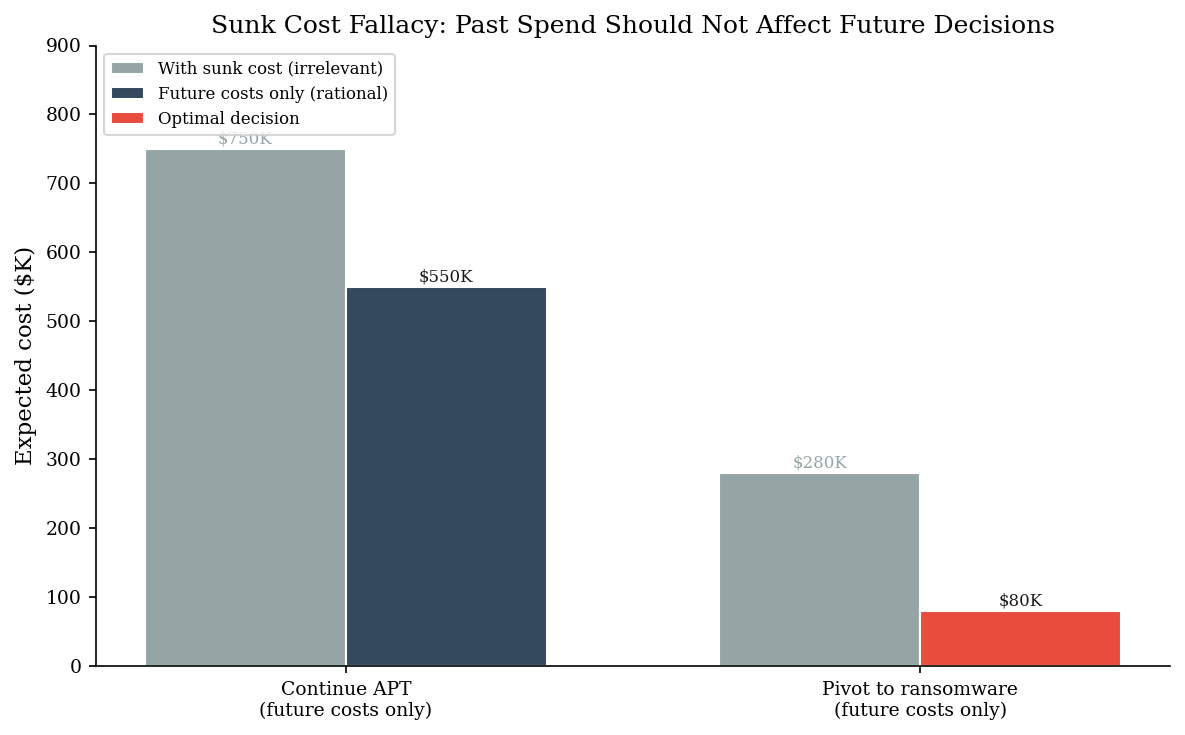

The $200K already spent is identical in both paths -- it cannot
influence the decision. Only future expected costs matter.


In [7]:
# --- Bar chart: Sunk Cost vs Rational Decision ---

fig, ax = plt.subplots(figsize=(8, 5))

# What the sunk-cost thinker sees (includes $200K already spent)
sunk_cost_view = {
    "Continue APT\n(sunk cost thinking)": sunk_cost + ev_continue_apt,
    "Pivot to ransomware\n(sunk cost thinking)": sunk_cost + ev_pivot,
}

# What the rational thinker sees (only future costs)
rational_view = {
    "Continue APT\n(future costs only)": ev_continue_apt,
    "Pivot to ransomware\n(future costs only)": ev_pivot,
}

labels = list(rational_view.keys())
rational_vals = list(rational_view.values())
sunk_vals = list(sunk_cost_view.values())

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, [v/1000 for v in sunk_vals], width,
               label="With sunk cost (irrelevant)", color=LIGHT_GRAY, edgecolor="white")
bars2 = ax.bar(x + width/2, [v/1000 for v in rational_vals], width,
               label="Future costs only (rational)", color=DARK_BG, edgecolor="white")

# Highlight the rational winner
ax.bar(x[1] + width/2, rational_vals[1]/1000, width,
       color=ACCENT, edgecolor="white", label="Optimal decision")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"${bar.get_height():.0f}K", ha="center", fontsize=8, color=LIGHT_GRAY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"${bar.get_height():.0f}K", ha="center", fontsize=8, color=PRIMARY)

ax.set_ylabel("Expected cost ($K)")
ax.set_title("Sunk Cost Fallacy: Past Spend Should Not Affect Future Decisions")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, max(sunk_vals)/1000 * 1.2)

plt.tight_layout()
plt.show()

print("The $200K already spent is identical in both paths -- it cannot")
print("influence the decision. Only future expected costs matter.")

## 4. The Resulting Trap

Annie Duke's concept of "resulting" describes the tendency to evaluate
decision quality by looking at outcomes rather than process. In security,
this is pervasive:

- The CISO who skipped the patch window and nothing happened gets praised
  for "not disrupting operations."
- The analyst who correctly escalated an alert that turned out to be a
  false positive gets criticized for "wasting the team's time."

The problem is that good decisions can produce bad outcomes (the firewall
rule was correct but the attacker found a different path) and bad
decisions can produce good outcomes (we left the vulnerability unpatched
and the attacker never found it).

> "The right question is, knowing what you did at that time, was
> [the decision] right?"

We simulate 100 security decisions, each with a known probability of
success. We classify each decision as "good process" or "bad process"
based on whether it maximized expected value. Then we compare decision
quality against actual outcomes to show how resulting misclassifies
decisions.

In [8]:
# --- The Resulting Trap: Decision Quality vs Outcome Quality ---

n_decisions = 100

# Each decision has a true probability of a good outcome
# (e.g., "if we patch now, 85% chance the system stays stable")
true_prob_good_outcome = rng.uniform(0.3, 0.95, size=n_decisions)

# "Good process" = decision-maker chose the action that maximized expected value
# We define: good process if they chose to act when P(good) > 0.5,
# or chose not to act when P(good) < 0.5
# Simulate: 70% of decision-makers follow good process, 30% don't
good_process = rng.random(n_decisions) < 0.70

# For good-process decisions, outcome probability is the true probability
# For bad-process decisions, outcome probability is inverted
# (they chose the wrong action, so P(good outcome) = 1 - true_prob)
effective_prob = np.where(good_process, true_prob_good_outcome, 1 - true_prob_good_outcome)

# Draw actual outcomes
good_outcome = rng.random(n_decisions) < effective_prob

# Build the 2x2 matrix
#                    Good Outcome    Bad Outcome
# Good Process:     Deserved win    Unlucky loss
# Bad Process:      Lucky win       Deserved loss

deserved_win = np.sum(good_process & good_outcome)
unlucky_loss = np.sum(good_process & ~good_outcome)
lucky_win = np.sum(~good_process & good_outcome)
deserved_loss = np.sum(~good_process & ~good_outcome)

confusion = pd.DataFrame(
    [[deserved_win, unlucky_loss],
     [lucky_win, deserved_loss]],
    index=["Good process", "Bad process"],
    columns=["Good outcome", "Bad outcome"],
)

print("=== Decision Quality x Outcome Quality ===\n")
print(confusion.to_string())

# "Resulting" = judging decisions by outcomes
# Misclassified = good process + bad outcome (punished) + bad process + good outcome (rewarded)
misclassified = unlucky_loss + lucky_win
total = n_decisions

print(f"\n--- Resulting Misclassification ---")
print(f"Good decisions punished (unlucky loss):   {unlucky_loss}")
print(f"Bad decisions rewarded (lucky win):        {lucky_win}")
print(f"Total misclassified by resulting:           {misclassified}/{total} ({misclassified/total:.0%})")

=== Decision Quality x Outcome Quality ===

              Good outcome  Bad outcome
Good process            42           27
Bad process             17           14

--- Resulting Misclassification ---
Good decisions punished (unlucky loss):   27
Bad decisions rewarded (lucky win):        17
Total misclassified by resulting:           44/100 (44%)


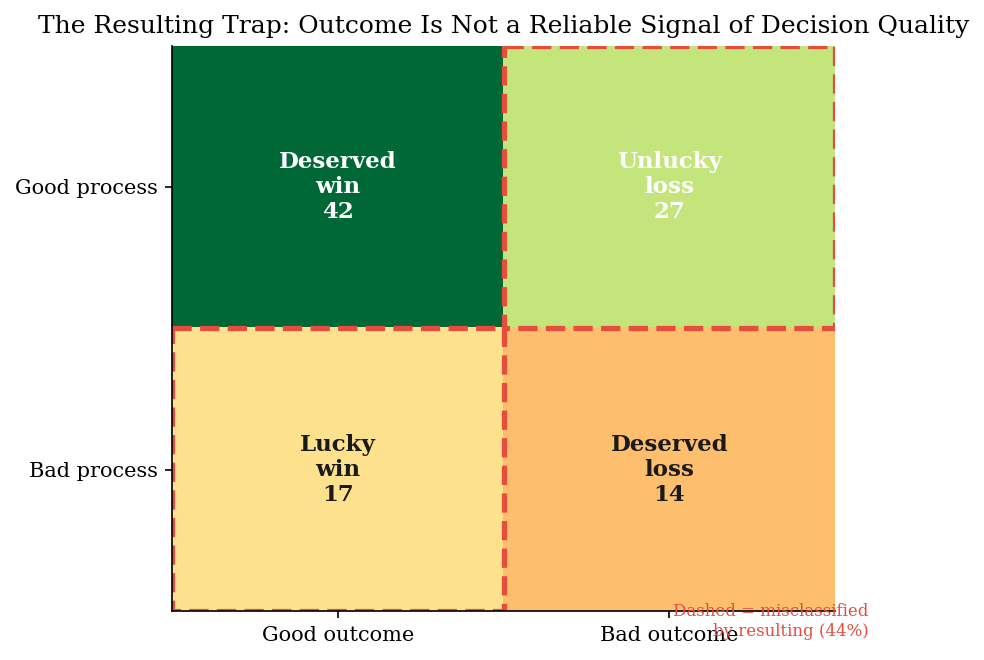

In [9]:
# --- Heatmap: The Resulting Matrix ---

fig, ax = plt.subplots(figsize=(6, 4.5))

matrix = confusion.values
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=matrix.max())

# Cell labels
cell_labels = [
    ["Deserved\nwin", "Unlucky\nloss"],
    ["Lucky\nwin", "Deserved\nloss"],
]

for i in range(2):
    for j in range(2):
        color = "white" if matrix[i, j] > matrix.max() * 0.6 else PRIMARY
        ax.text(j, i, f"{cell_labels[i][j]}\n{matrix[i, j]}",
                ha="center", va="center", fontsize=11, fontweight="bold",
                color=color)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Good outcome", "Bad outcome"], fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Good process", "Bad process"], fontsize=10)
ax.set_title("The Resulting Trap: Outcome Is Not a Reliable Signal of Decision Quality")

# Highlight the misclassified quadrants
for j, i in [(1, 0), (0, 1)]:  # unlucky loss, lucky win
    rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=2.5,
                          edgecolor=ACCENT, facecolor="none", linestyle="--")
    ax.add_patch(rect)

ax.text(1.6, 1.6, f"Dashed = misclassified\nby resulting ({misclassified}%)",
        fontsize=8, color=ACCENT, ha="right", va="bottom",
        transform=ax.transData)

plt.tight_layout()
plt.show()

## 5. Debiasing: Analysis of Competing Hypotheses (ACH)

Structured Analytic Techniques were developed by the CIA's Directorate of
Intelligence specifically to counteract confirmation bias in intelligence
analysis. The most widely used technique is **Analysis of Competing
Hypotheses** (ACH), introduced by Richards Heuer in *Psychology of
Intelligence Analysis* (1999).

The method forces the analyst to:
1. List all plausible hypotheses (not just the leading one)
2. List all available evidence
3. For each hypothesis-evidence pair, mark whether the evidence is
   **Consistent (C)**, **Inconsistent (I)**, or **Neutral (N)**
4. Count inconsistencies per hypothesis
5. Reject hypotheses with the most inconsistencies

The key insight is counterintuitive: ACH focuses on **disconfirming**
evidence rather than confirming evidence. A hypothesis survives not
because lots of evidence supports it, but because little evidence
contradicts it. This directly counteracts confirmation bias, which
amplifies confirming evidence and ignores contradictions.

**Scenario:** Same data exfiltration alert. Three competing hypotheses.

In [10]:
# --- Analysis of Competing Hypotheses (ACH) Matrix ---

hypotheses = ["Malicious insider", "External attacker\n(compromised creds)", "Misconfigured\nDLP rule"]
hyp_short = ["Insider", "External", "DLP misconfig"]

evidence_ach = [
    "Employee accessed files outside role",
    "Transfer occurred after business hours",
    "Credential found on dark-web paste",
    "Same alert on 3 other endpoints",
    "Transfer matches backup job timing",
    "No TLS on transfer (backups use TLS)",
]

# ACH matrix: C = Consistent, I = Inconsistent, N = Neutral
# Rows = evidence, Columns = hypotheses
ach_matrix = np.array([
    # Insider  External  DLP misconfig
    [  1,       0,        -1],    # Files outside role: C for insider, N for ext, I for DLP
    [  1,       1,         0],    # After hours: C for insider & external, N for DLP
    [ -1,       1,         0],    # Dark-web paste: I for insider, C for external, N for DLP
    [ -1,       0,         1],    # Same alert 3 endpoints: I for insider, N for ext, C for DLP
    [  0,      -1,         1],    # Matches backup timing: N for insider, I for ext, C for DLP
    [  1,       1,        -1],    # No TLS: C for insider & ext, I for DLP
])

# Map to labels
label_map = {1: "C", 0: "N", -1: "I"}

# Build display DataFrame
ach_display = pd.DataFrame(
    [[label_map[v] for v in row] for row in ach_matrix],
    index=evidence_ach,
    columns=hyp_short,
)

# Count inconsistencies
inconsistencies = (ach_matrix == -1).sum(axis=0)
consistencies = (ach_matrix == 1).sum(axis=0)

ach_display.loc["---"] = ["---"] * 3
ach_display.loc["Inconsistencies (I)"] = inconsistencies
ach_display.loc["Consistencies (C)"] = consistencies

print("=== ACH Matrix ===\n")
print(ach_display.to_string())

print(f"\n--- ACH Verdict ---")
survivor_idx = np.argmin(inconsistencies)
print(f"Fewest inconsistencies: {hyp_short[survivor_idx]} ({inconsistencies[survivor_idx]} I's)")
print(f"ACH does not confirm a hypothesis -- it rejects the ones with")
print(f"the most contradictory evidence.")

=== ACH Matrix ===

                                       Insider External DLP misconfig
Employee accessed files outside role         C        N             I
Transfer occurred after business hours       C        C             N
Credential found on dark-web paste           I        C             N
Same alert on 3 other endpoints              I        N             C
Transfer matches backup job timing           N        I             C
No TLS on transfer (backups use TLS)         C        C             I
---                                        ---      ---           ---
Inconsistencies (I)                          2        1             2
Consistencies (C)                            3        3             2

--- ACH Verdict ---
Fewest inconsistencies: External (1 I's)
ACH does not confirm a hypothesis -- it rejects the ones with
the most contradictory evidence.


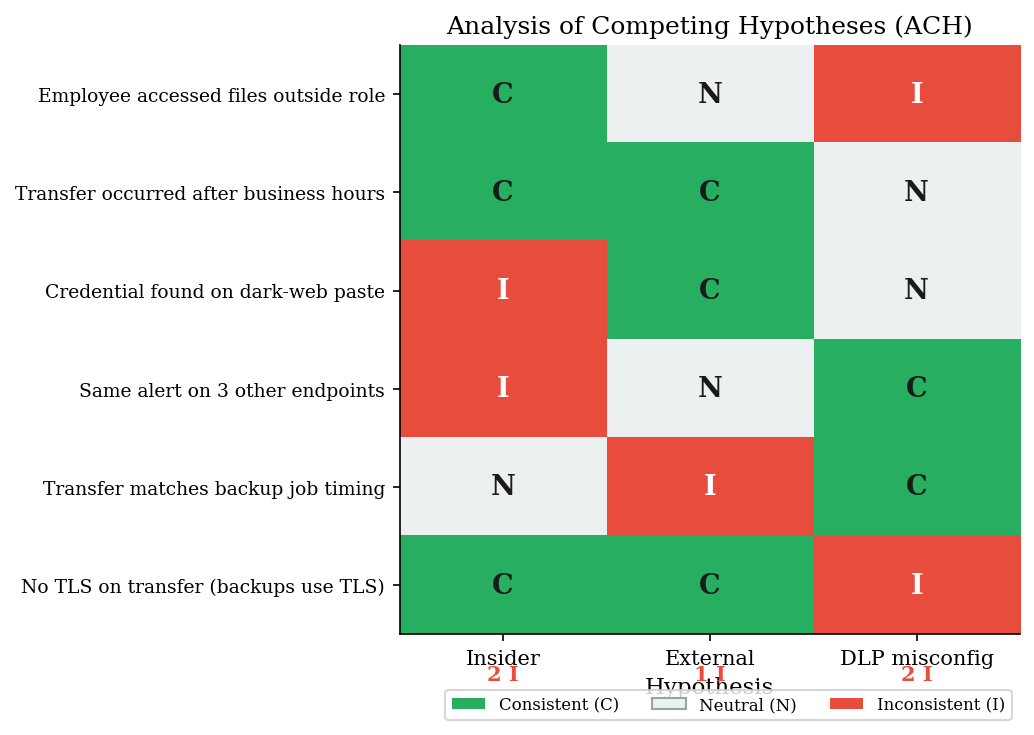

In [11]:
# --- ACH Heatmap Visualization ---

fig, ax = plt.subplots(figsize=(7, 5))

# Color map: I=-1 -> red, N=0 -> light gray, C=1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#E74C3C", "#ECF0F1", "#27AE60"])

im = ax.imshow(ach_matrix, cmap=cmap, aspect="auto", vmin=-1, vmax=1)

# Cell text
for i in range(ach_matrix.shape[0]):
    for j in range(ach_matrix.shape[1]):
        val = ach_matrix[i, j]
        label = label_map[val]
        color = "white" if val == -1 else PRIMARY
        ax.text(j, i, label, ha="center", va="center",
                fontsize=13, fontweight="bold", color=color)

# Axis labels
ax.set_xticks(range(len(hyp_short)))
ax.set_xticklabels(hyp_short, fontsize=10)
ax.set_yticks(range(len(evidence_ach)))
ax.set_yticklabels(evidence_ach, fontsize=9)

ax.set_title("Analysis of Competing Hypotheses (ACH)")
ax.set_xlabel("Hypothesis")

# Add inconsistency count below
for j, count in enumerate(inconsistencies):
    ax.text(j, len(evidence_ach) - 0.2, f"{count} I",
            ha="center", va="top", fontsize=10, fontweight="bold",
            color=ACCENT,
            transform=ax.transData)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#27AE60", label="Consistent (C)"),
    Patch(facecolor="#ECF0F1", edgecolor=LIGHT_GRAY, label="Neutral (N)"),
    Patch(facecolor="#E74C3C", label="Inconsistent (I)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8,
          bbox_to_anchor=(1.0, -0.08), ncol=3)

plt.tight_layout()
plt.show()

## 6. Pitfalls

**Belief perseverance strengthens with public commitment.** Once the
analyst has told the SOC manager "this is an insider threat," the
psychological cost of reversing that judgment doubles. The analyst is
no longer just updating a belief -- they are admitting they were wrong
in front of their team. IR post-mortems should evaluate evidence
interpretation, not just outcomes, and organizations should reward
analysts who update their hypotheses in response to new evidence.

**Confirmation bias is invisible to the person experiencing it.** The
biased analyst genuinely believes they are being objective. They are not
lying about the evidence -- they are *seeing* the evidence differently
because their hypothesis is filtering their perception. This is why
structured techniques like ACH exist: they externalize the reasoning
process and make selective attention visible.

**Sunk costs are amplified by loss aversion.** Kahneman and Tversky's
prospect theory predicts that people become risk-seeking when facing
losses. An IR team that has already spent $200K on an APT investigation
is in the loss domain -- pivoting means *realizing* that loss. Continuing
the APT investigation is a gamble that might justify the spend. The
sunk cost fallacy and loss aversion reinforce each other, making the
pivot even harder than the raw numbers suggest.

**"Resulting" punishes good process and rewards lucky negligence.** If
your organization evaluates security decisions by whether an incident
occurred, you are building incentives for luck-seeking behavior. The
CISO who delays patching and gets lucky looks better than the CISO who
patches on schedule and experiences a brief outage. Over time, this
selects for risk-taking disguised as efficiency. The antidote is
decision journals: log what you knew, what you decided, and why --
*before* the outcome is known. Evaluate the log, not the headline.

---

*Next: Part 2.2 explores base rate neglect and the prosecutor's fallacy
in security alert triage -- why a 99.9% accurate threat detector still
produces mostly false positives when the base rate of real attacks is
low.*